# Asheboro Simulation Outcomes

In [1]:
# Import the necessary packages
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from itertools import product, chain
BASE_DIR = Path().resolve()

In [2]:
# Create a string and list to read in all files.
start_title = ["asheboro_sims_"]
election_title = ["Asheboro BoE ", "Asheboro Council "]
demographics = ["Bachelors Degree", "Black", "High School Diploma", "Hispanic", "Some College", "White"]
end_title = ["_BT.csv", "_PL.csv", "_Cam.csv"]

# Find every possible combination, then join into list of strings
csv_list = list(product(start_title, election_title, demographics, end_title))
csv_titles = [[''.join(elem)] for elem in csv_list] # Source: https://stackoverflow.com/questions/72186008/python-join-strings-in-list-of-lists; https://stackoverflow.com/questions/11264684/flatten-list-of-lists
csv_titles = list(chain.from_iterable(csv_titles)) # Flatten into one list 
# Now we have a list of all the csvs we need to read-in and analyze!

In [ ]:
# Read in all the csvs into a list of pandas dataframes
df_list = []

for i in csv_titles:
    df_list.append(pd.read_csv(BASE_DIR / "New_Simulation_Results" / "Elections" / "asheboro sims" / i))


asheboro_sims_Asheboro BoE Bachelors Degree_BT.csv
plurality winner:  ("['Gidget Kidd', 'Melissa Calloway', 'Ryan Patton']", 8189)
rcv winner:  ("['Gidget Kidd', 'Melissa Calloway', 'Ryan Patton']", 8985)
{"['Gidget Kidd', 'Melissa Calloway', 'Ryan Patton']": 8985, "['Melissa Calloway', 'Ryan Patton', 'Todd Dulaney']": 25, "['Gidget Kidd', 'Gwen Williams', 'Melissa Calloway']": 682, "['Gwen Williams', 'Melissa Calloway', 'Ryan Patton']": 198, "['Gidget Kidd', 'Gwen Williams', 'Ryan Patton']": 44, "['Gidget Kidd', 'Melissa Calloway', 'Todd Dulaney']": 62, "['Gidget Kidd', 'Ryan Patton', 'Todd Dulaney']": 4}
['mediumseagreen', 'plum', 'plum', 'plum', 'plum', 'plum', 'plum']
asheboro_sims_Asheboro BoE Bachelors Degree_PL.csv
plurality winner:  ("['Gidget Kidd', 'Melissa Calloway', 'Ryan Patton']", 9583)
rcv winner:  ("['Gidget Kidd', 'Melissa Calloway', 'Ryan Patton']", 9331)
{"['Gidget Kidd', 'Melissa Calloway', 'Ryan Patton']": 9331, "['Gidget Kidd', 'Gwen Williams', 'Melissa Calloway']

/var/folders/tx/qckl6gp57yq_ckc0ywsl5vlh0000gn/T/ipykernel_60166/3780224560.py:68: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


rcv winner:  ("['Charles Swiers', 'Eddie Burks', 'Joey Trogdon']", 7091)
{"['Charles Swiers', 'Eddie Burks', 'Jane Hughes Redding']": 2909, "['Charles Swiers', 'Eddie Burks', 'Joey Trogdon']": 7091}
['plum', 'mediumseagreen']
asheboro_sims_Asheboro Council Black_PL.csv
plurality winner:  ("['Charles Swiers', 'Eddie Burks', 'Joey Trogdon']", 7468)
rcv winner:  ("['Charles Swiers', 'Eddie Burks', 'Joey Trogdon']", 7225)
{"['Charles Swiers', 'Eddie Burks', 'Jane Hughes Redding']": 2775, "['Charles Swiers', 'Eddie Burks', 'Joey Trogdon']": 7225}
['plum', 'mediumseagreen']
asheboro_sims_Asheboro Council Black_Cam.csv
plurality winner:  ("['Charles Swiers', 'Eddie Burks', 'Joey Trogdon']", 7431)
rcv winner:  ("['Charles Swiers', 'Eddie Burks', 'Joey Trogdon']", 7195)
{"['Charles Swiers', 'Eddie Burks', 'Jane Hughes Redding']": 2805, "['Charles Swiers', 'Eddie Burks', 'Joey Trogdon']": 7195}
['plum', 'mediumseagreen']
asheboro_sims_Asheboro Council High School Diploma_BT.csv
plurality winner:

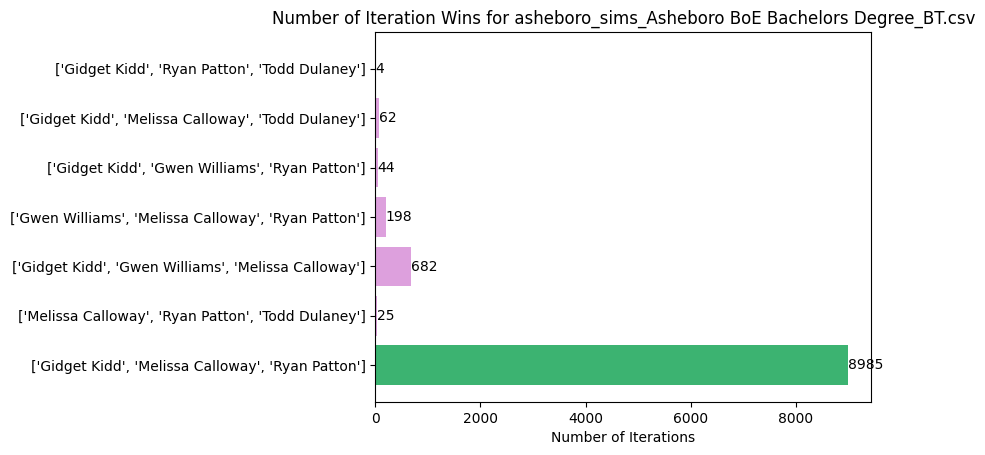

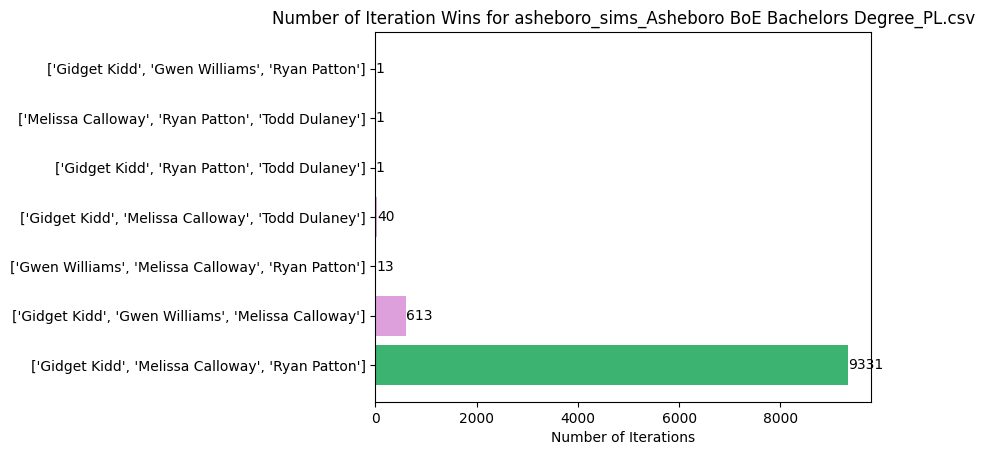

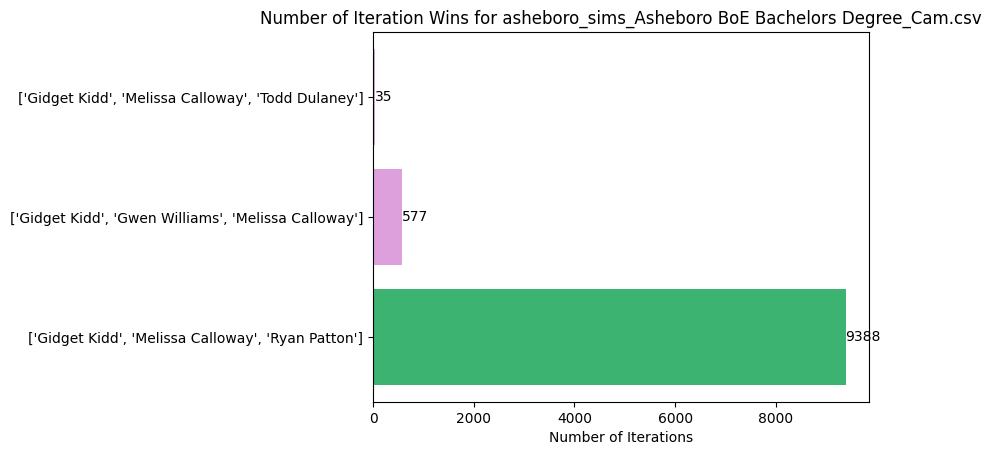

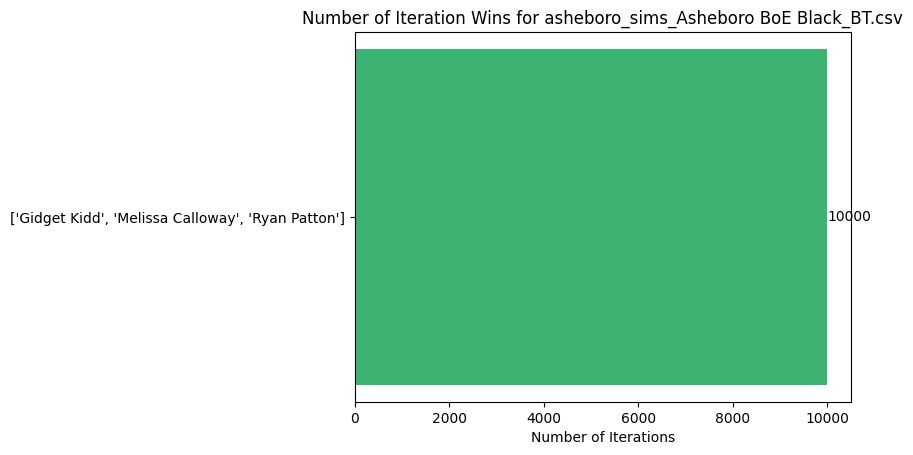

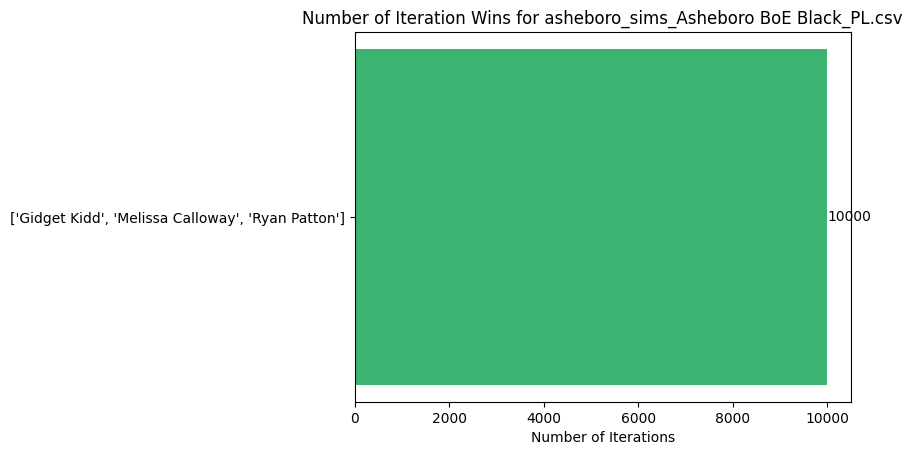

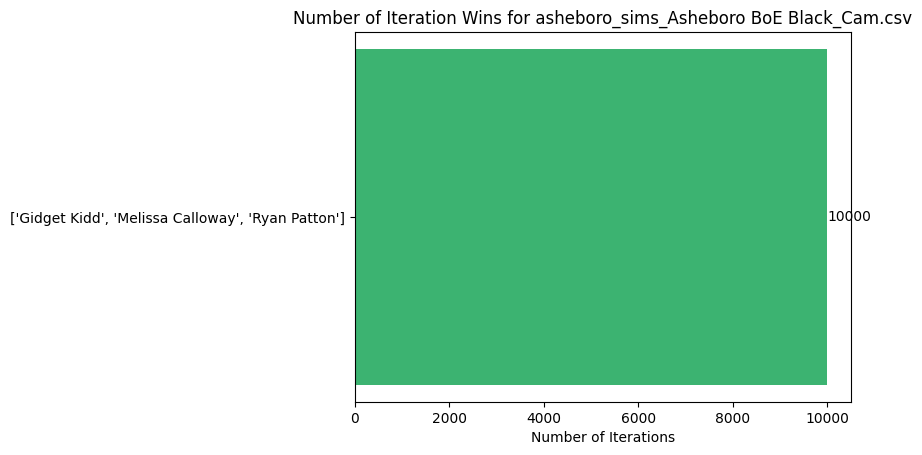

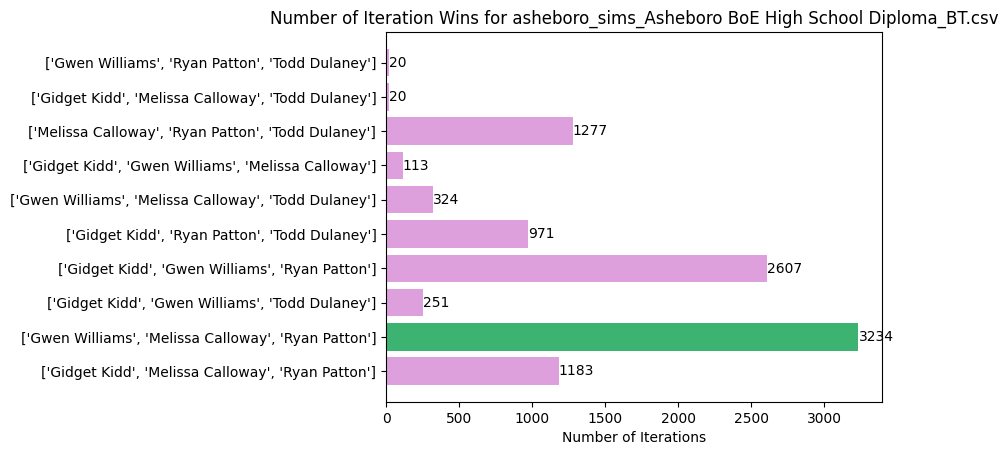

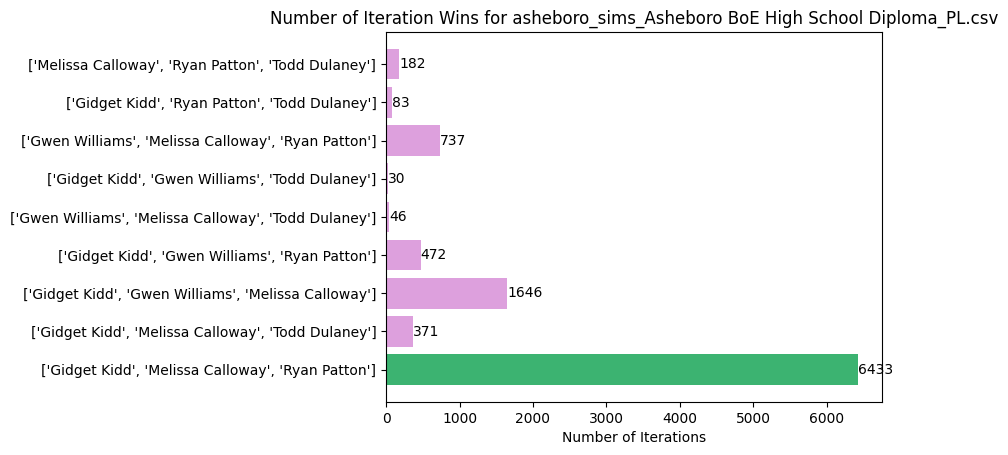

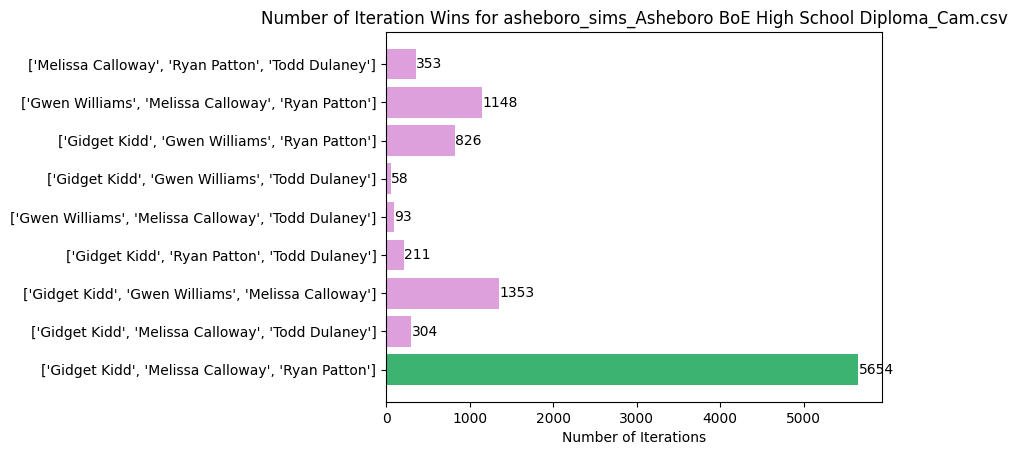

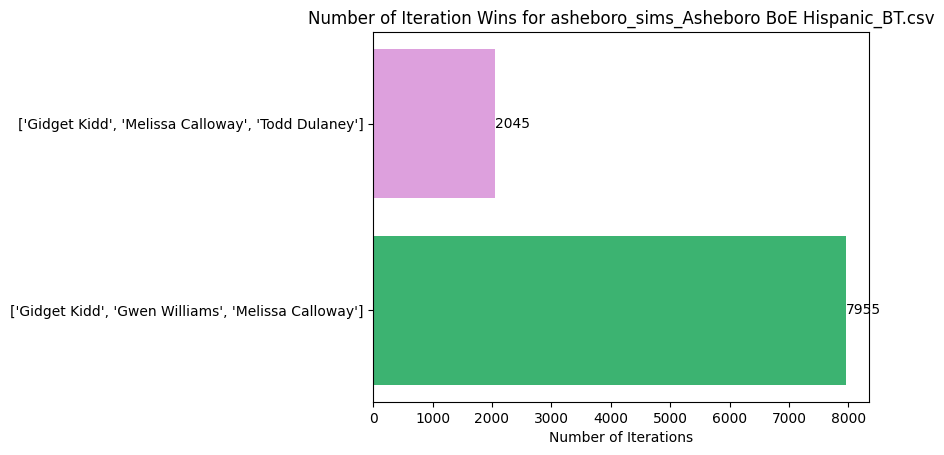

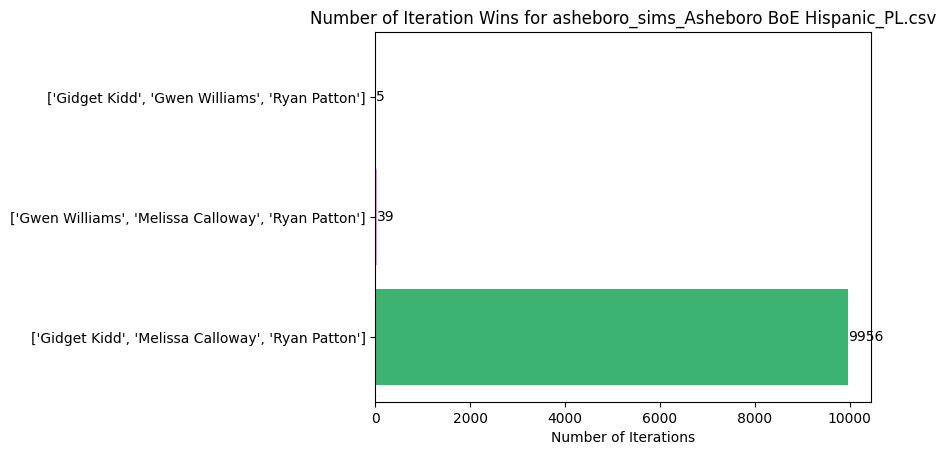

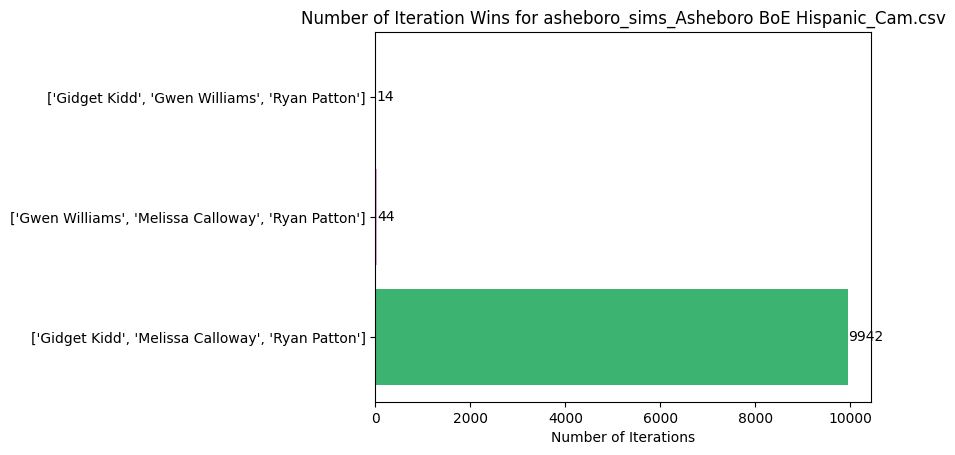

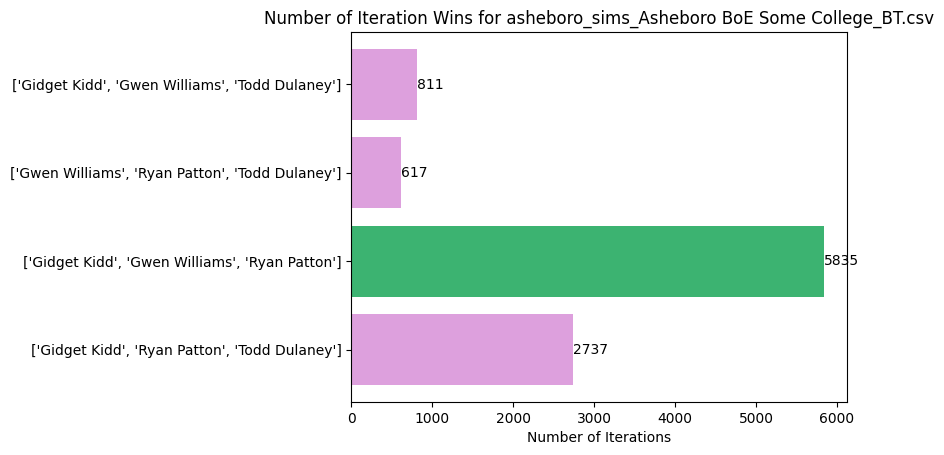

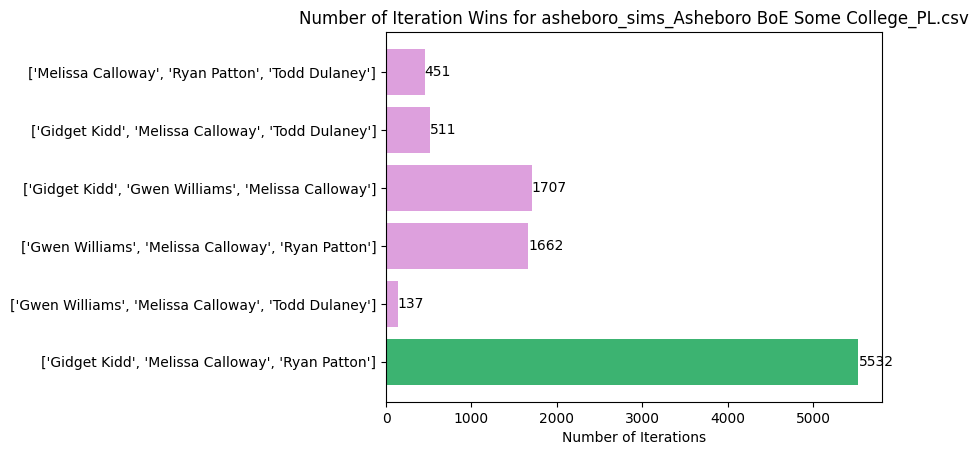

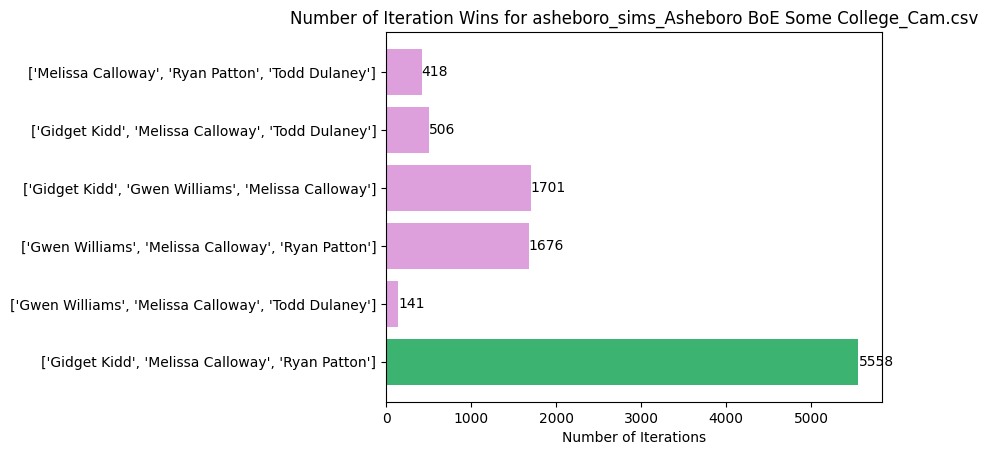

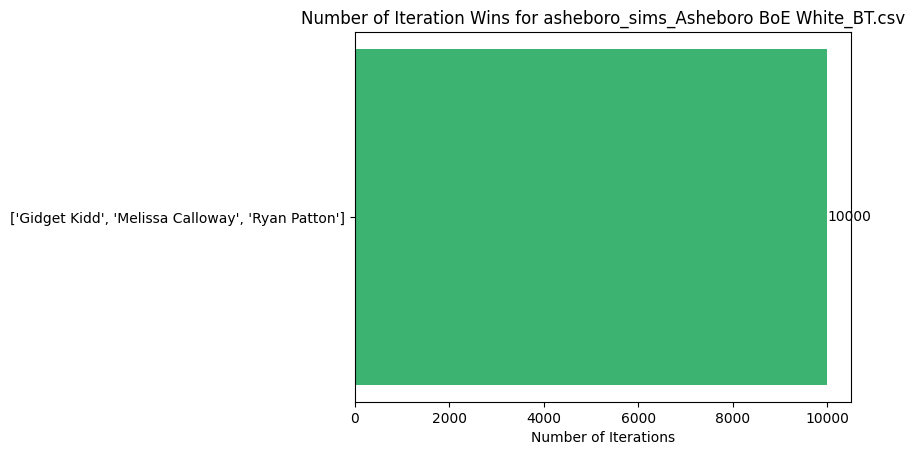

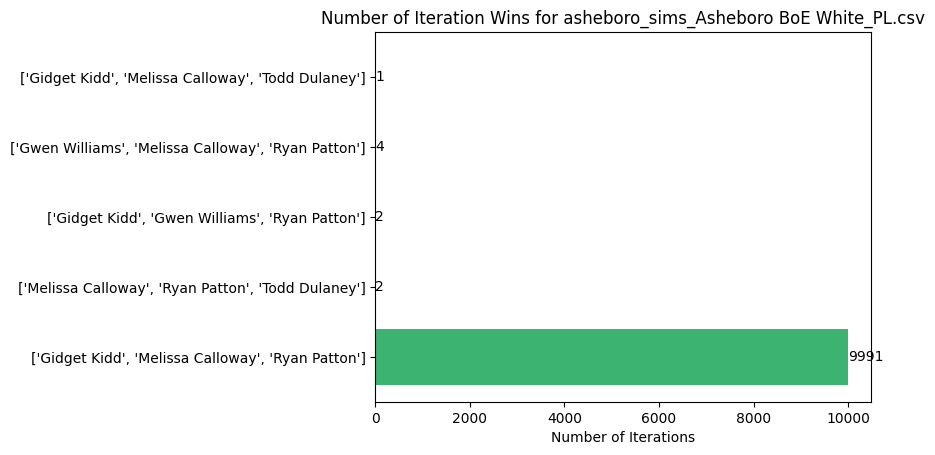

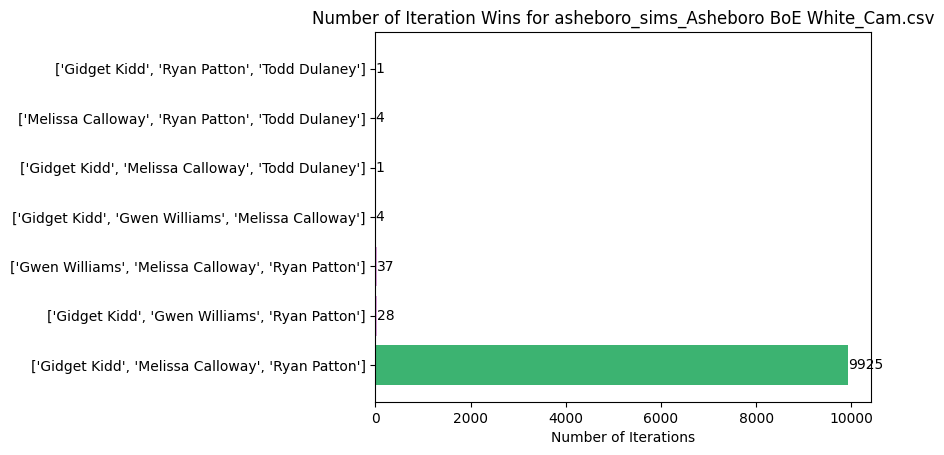

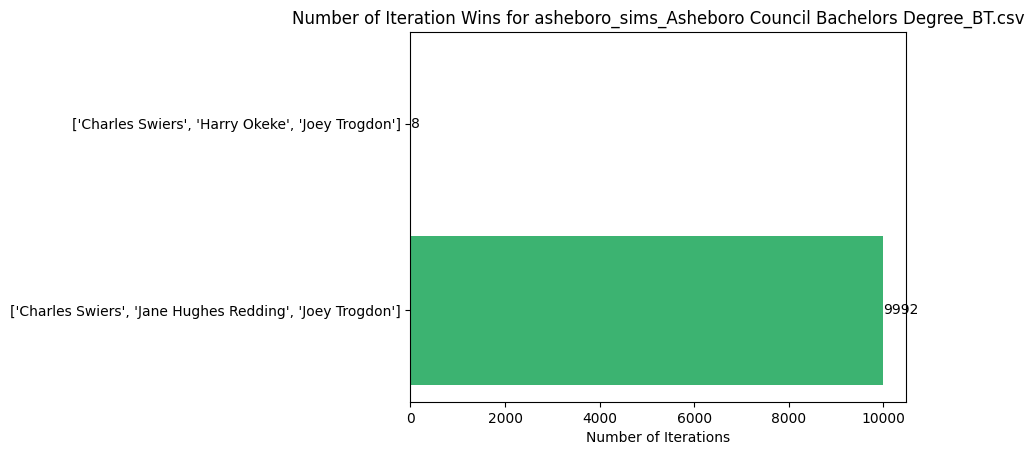

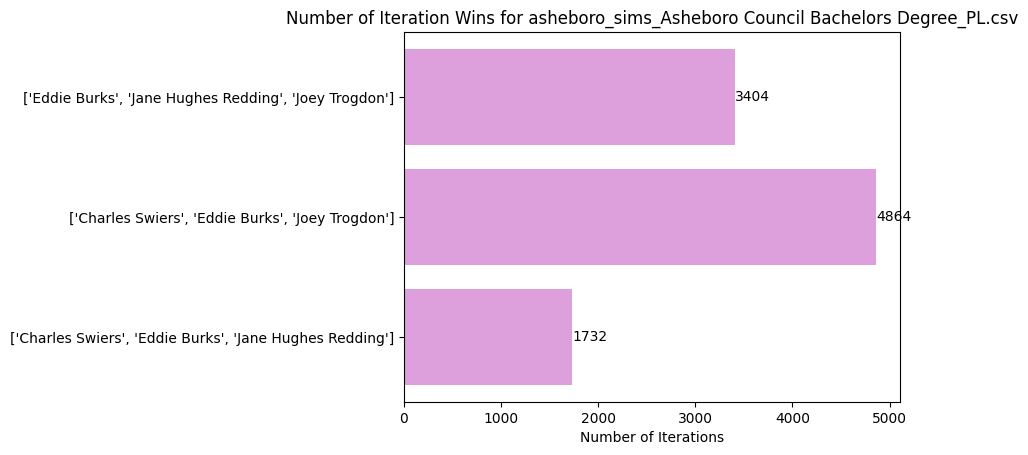

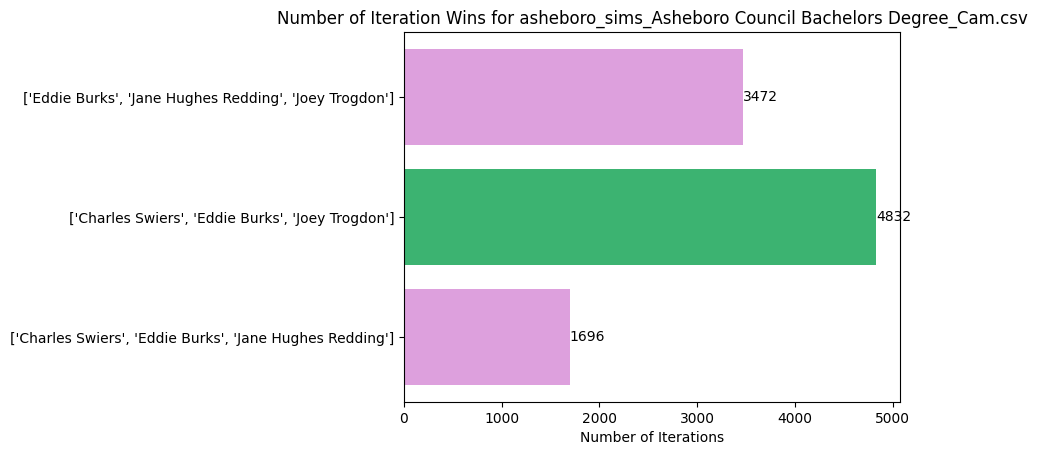

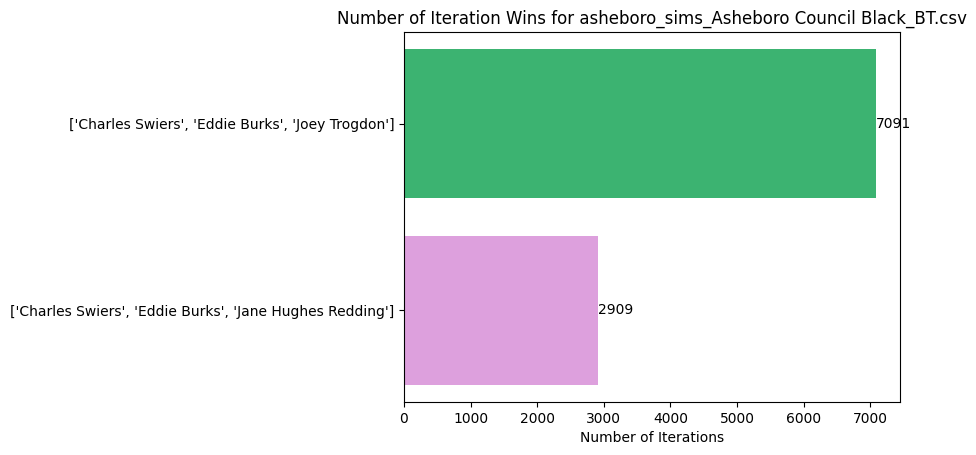

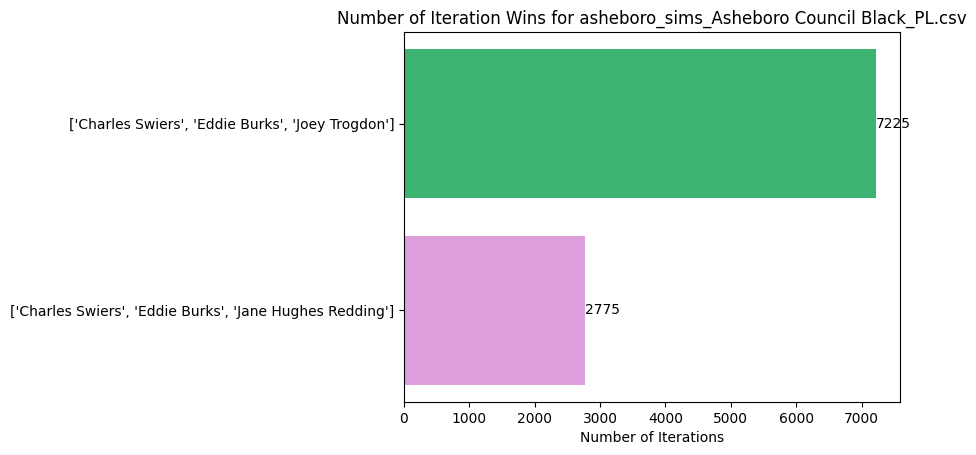

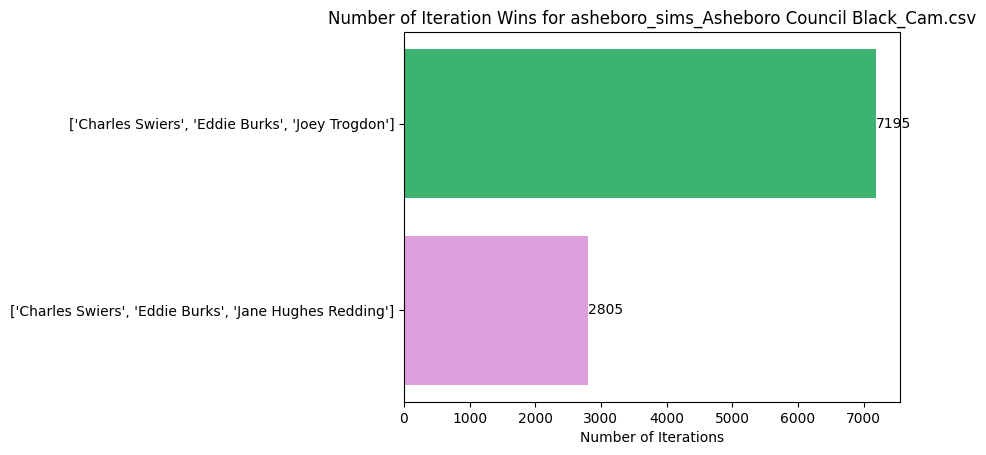

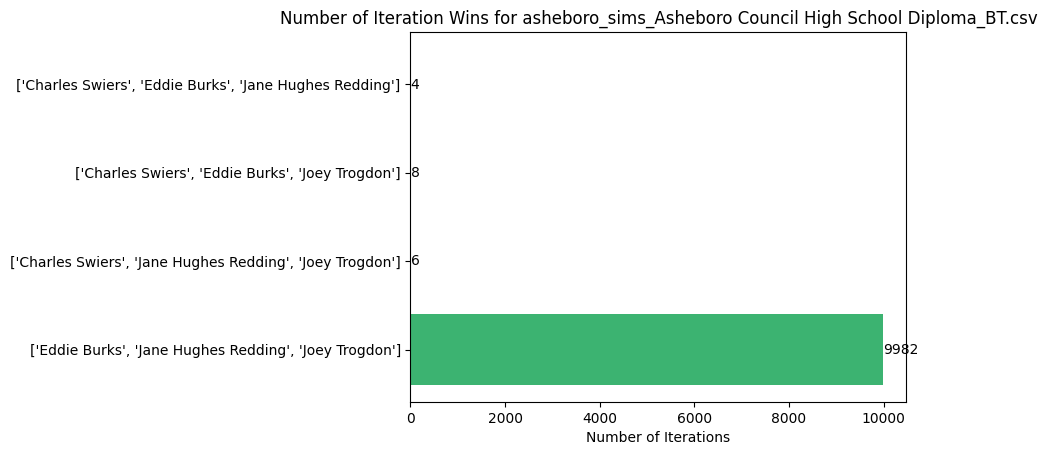

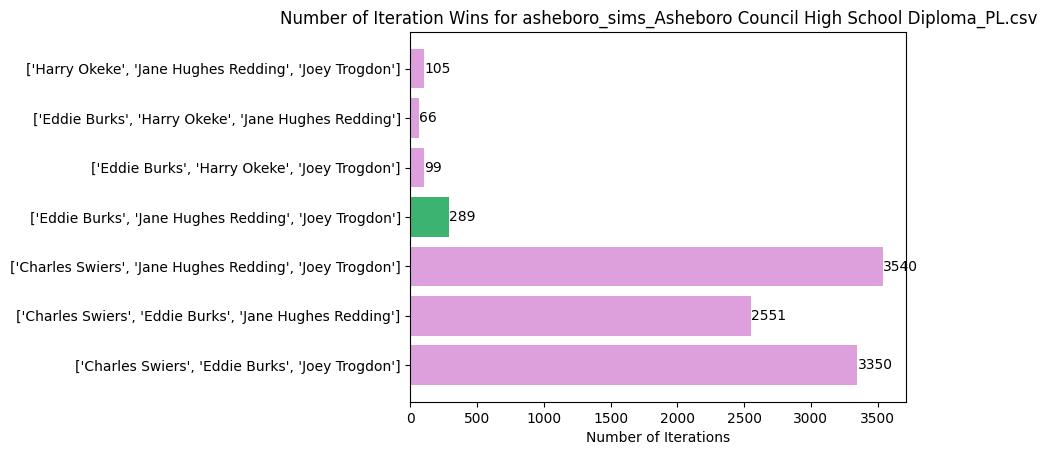

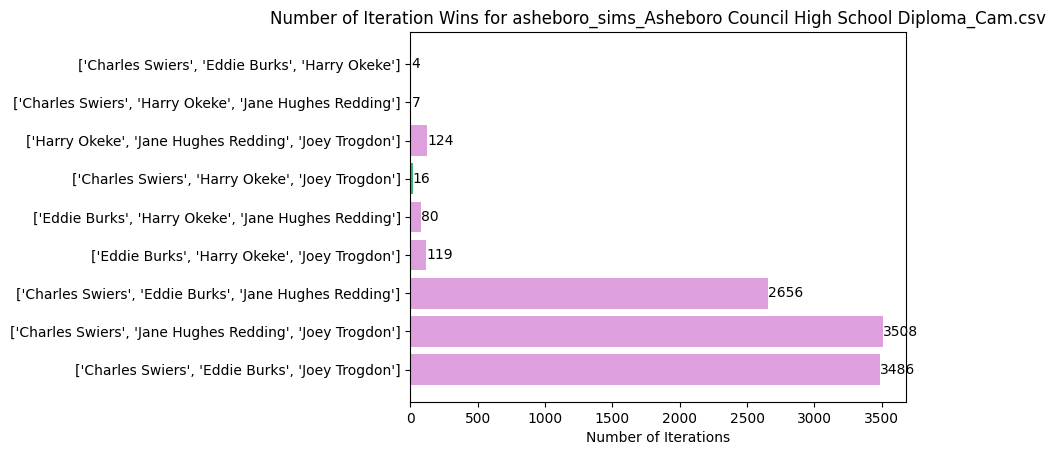

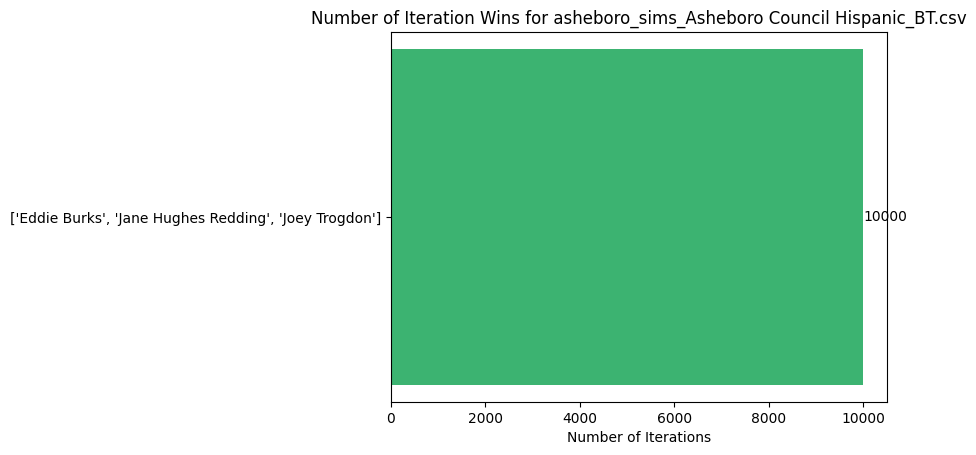

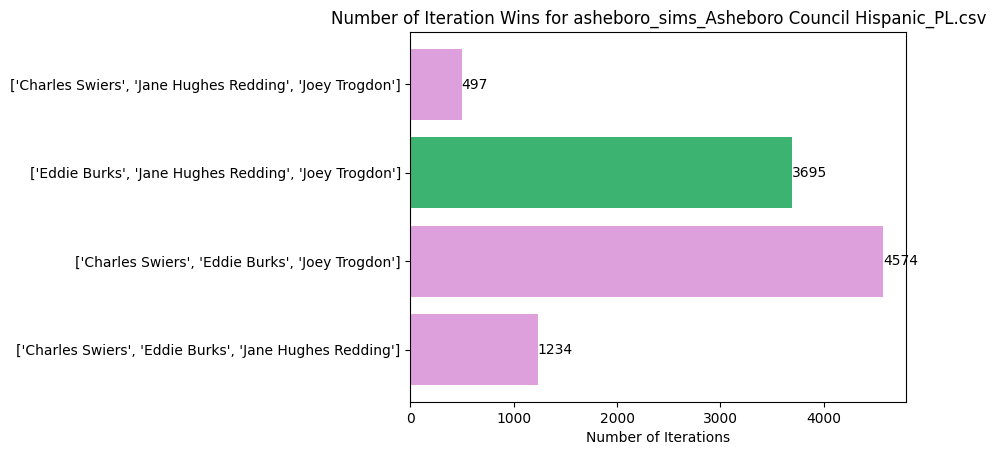

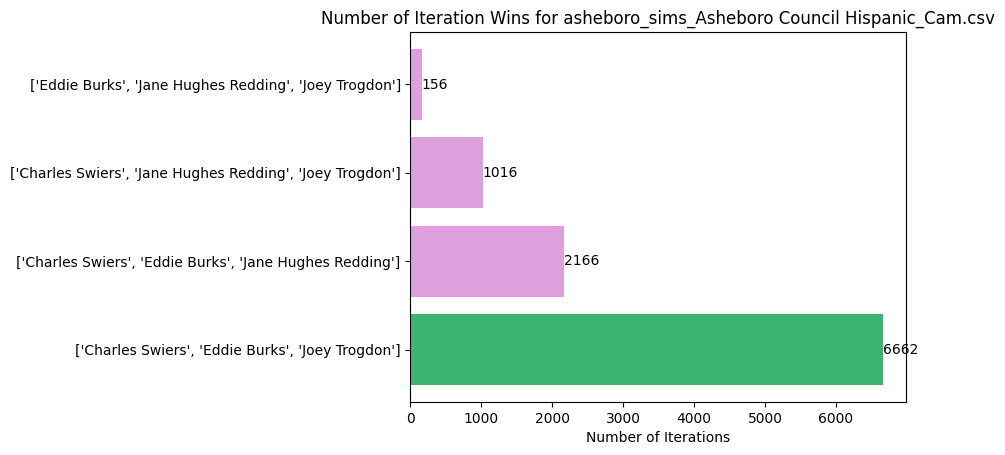

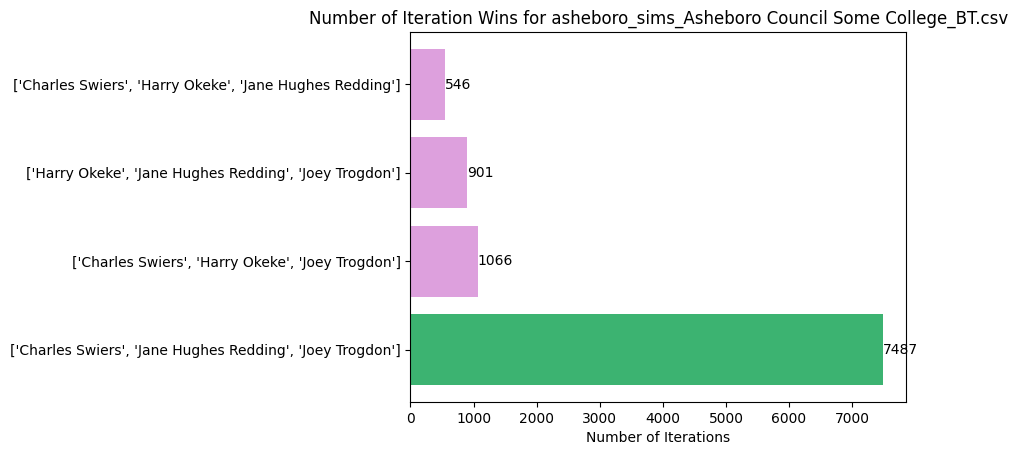

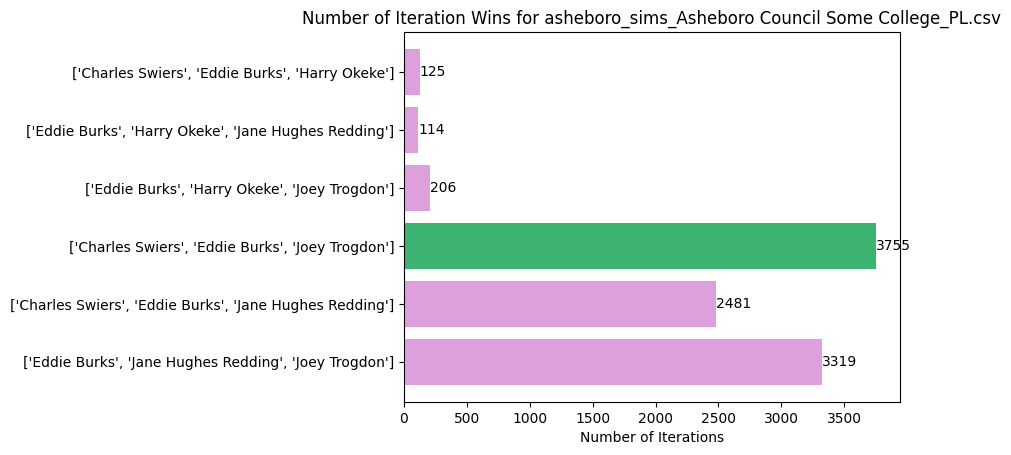

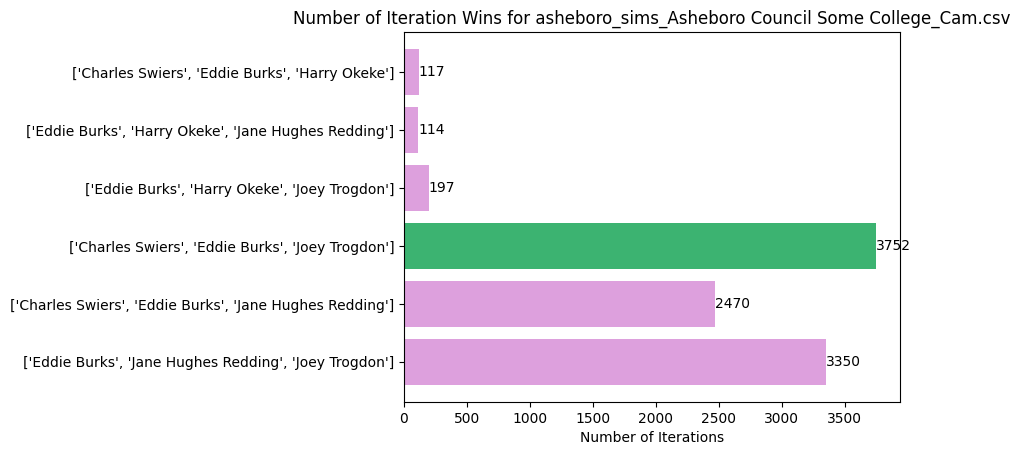

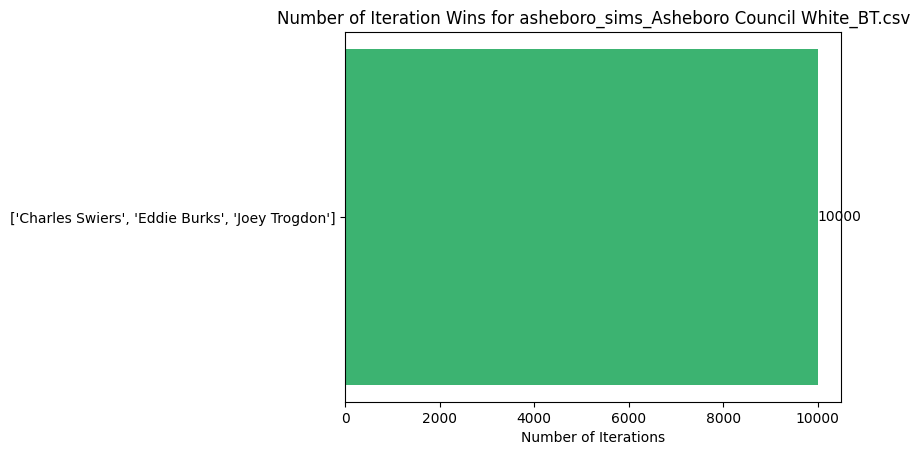

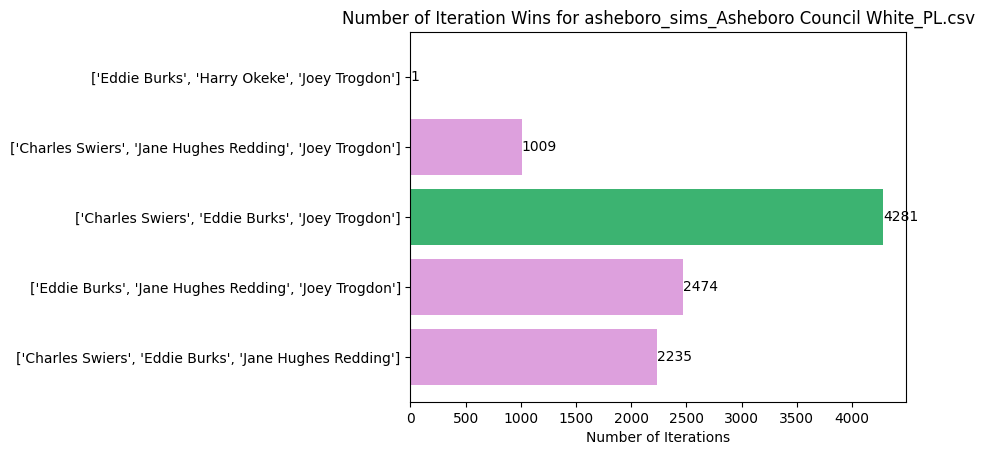

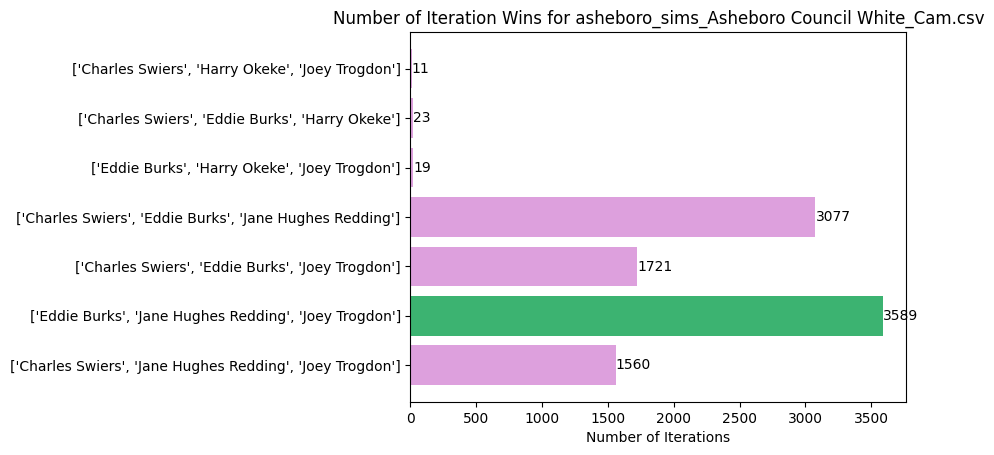

In [5]:
# Determine Plurality Winner

for i in range(len(df_list)):
    print(csv_titles[i])
    # Get plurality winner to set colors
    num_candidates = int(df_list[i]['Candidate'].isna().idxmax())
   
    df_list[i] = df_list[i].dropna().reset_index()
    grps = df_list[i].groupby(df_list[i].index // num_candidates)
    all_winners = []
    for _, dfg in grps:
        winners = dfg[dfg['Plurality Result'] == True]
        winners = winners['Candidate'] 
        all_winners.append(list(winners))

    all_winners = tuple(all_winners)

    counts = {}
    for j in all_winners:
        j = str(j)
        if j in counts:
            counts[j] += 1
        else:
            counts[j] = 1

    # Inspiration from: https://medium.com/@icodewithben/counting-and-graphing-categorical-data-with-matplotlib-017ac6d4aa73
    winners = list(counts.keys())
    values = list(counts.values())

    # Get overall winner
    plurality_winner = max(counts.items(), key=lambda item: item[1])

    print('plurality winner: ', plurality_winner)

    # Get ranked-choice winnner
    grps = df_list[i].groupby(df_list[i].index // num_candidates)
    all_winners = []
    for _, dfg in grps:
        winners = dfg[dfg['STV Result'] == True]
        winners = winners['Candidate'] 
        all_winners.append(list(winners))

    all_winners = tuple(all_winners)

    counts = {}
    for j in all_winners:
        j = str(j)
        if j in counts:
            counts[j] += 1
        else:
            counts[j] = 1

    # Inspiration from: https://medium.com/@icodewithben/counting-and-graphing-categorical-data-with-matplotlib-017ac6d4aa73
    winners = list(counts.keys())
    values = list(counts.values())

    # Get overall winner
    rcv_winner = max(counts)
    rcv_winner = max(counts.items(), key=lambda item: item[1])

    print('rcv winner: ', rcv_winner)
    # Now, assign colors based on plurality winner
    print(counts)
    
    colors = ['plum' if i != plurality_winner[0] else 'mediumseagreen' for i in winners]
    print(colors)

    fig, ax = plt.subplots()
    #ax.barh(winners, values, color = colors)
    ax.barh(counts.keys(), counts.values(), color = colors)
    for container in ax.containers:
        ax.bar_label(container)
    plt.xlabel('Number of Iterations')
    plt.title("Number of Iteration Wins for " + csv_titles[i])

    